# AI System Implementation - Exploring difference approches

- dataset: food101

## Importing Library

In [44]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import math
import time
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import pandas as pd
import numpy as np

## Downloading dataset

In [2]:
# ds, info = tfds.load('food101', split='train', as_supervised=True, with_info=True)
dataset_name = "food101"
train_dataset = tfds.load(dataset_name, split="train", as_supervised=True)
test_dataset = tfds.load(dataset_name, split="validation", as_supervised=True)  # Using predefined test set
info = tfds.builder(dataset_name).info

## Understanding the dataset

In [3]:
info

tfds.core.DatasetInfo(
    name='food101',
    full_name='food101/2.0.0',
    description="""
    This dataset consists of 101 food categories, with 101'000 images. For each class, 250 manually reviewed test images are provided as well as 750 training images. On purpose, the training images were not cleaned, and thus still contain some amount of noise. This comes mostly in the form of intense colors and sometimes wrong labels. All images were rescaled to have a maximum side length of 512 pixels.
    """,
    homepage='https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/',
    data_dir='/root/tensorflow_datasets/food101/2.0.0',
    file_format=tfrecord,
    download_size=4.65 GiB,
    dataset_size=4.77 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=101),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    splits={
        'train': <SplitInfo nu

## Limited Classes

In [4]:
CLASSES = 10 # Number of classes

In [5]:
# Get only the first `CLASSES` labels
selected_classes = tf.constant(list(range(CLASSES)), dtype=tf.int64)
labels = info.features['label'].names[:CLASSES]

# Efficient function to filter dataset based on selected classes
def filter_classes(image, label):
    return tf.reduce_any(tf.equal(label, selected_classes))

# Apply filtering
filtered_train_dataset = train_dataset.filter(filter_classes)
test_ds = test_dataset.filter(filter_classes)

In [6]:
# Get dataset sizes efficiently
def dataset_size(dataset):
    return dataset.reduce(tf.constant(0), lambda x, _: x + 1).numpy()

train_size = dataset_size(filtered_train_dataset)
test_size = dataset_size(test_ds)

print(f"Filtered Train dataset size: {train_size}")
print(f"Filtered Test dataset size: {test_size}")

Filtered Train dataset size: 7500
Filtered Test dataset size: 2500


## Visaulizing Sample Images

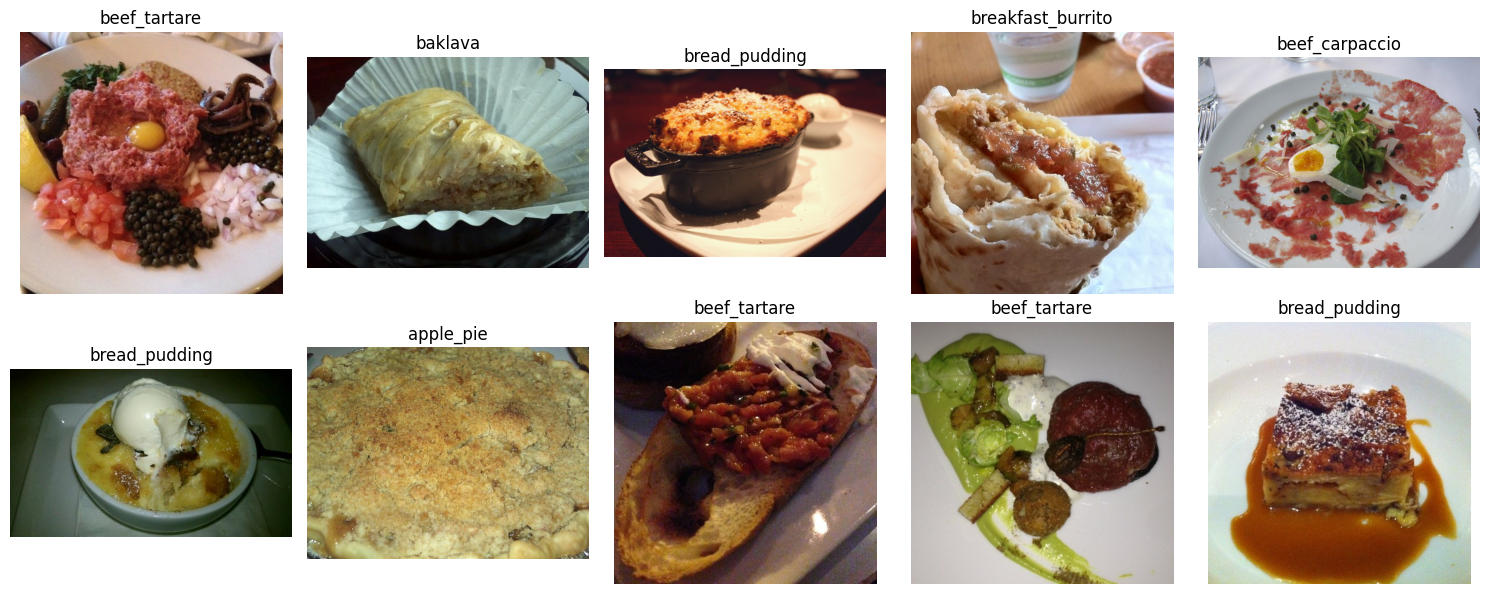

In [7]:
# Dynamically determine the grid size for plotting
cols = min(CLASSES, 5)  # Max 5 columns for better layout
rows = math.ceil(CLASSES / cols)

# Create visualization grid
plt.figure(figsize=(cols * 3, rows * 3))  # Adjust figure size dynamically
for i, (image, label) in enumerate(filtered_train_dataset.take(CLASSES)):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(image.numpy().astype('uint8'))
    plt.title(labels[label.numpy()])
    plt.axis('off')

plt.tight_layout()
plt.show()

## Shuffle before Splitting

In [8]:
# Shuffle before splitting (Ensures random train/validation split)
filtered_train_dataset = filtered_train_dataset.shuffle(10000, reshuffle_each_iteration=False)

## Dataset Splitting

In [9]:
train_split = 0.8
full_train_size = train_size
train_size = int(train_split * full_train_size)

train_ds = filtered_train_dataset.take(train_size)
val_ds = filtered_train_dataset.skip(train_size)

train_size = dataset_size(train_ds)
val_size = dataset_size(val_ds)

print(f"Filtered Train set size: {train_size}")
print(f"Filtered Validation set size: {val_size}")

Filtered Train set size: 6000
Filtered Validation set size: 1500


## Feature engineering & Data Augmentation

### Standardizing & Normalizing Pixel Values

In [10]:
# Normalize pixel values to [0,1]
def normalize(image, label):
    image = tf.image.convert_image_dtype(image, tf.float32)  # Converts from [0, 255] → [0, 1]
    return image, label

### Common Augmentations for Image Classification

In [11]:
# Define augmentation function
def augment(image, label):
    image = tf.image.random_flip_left_right(image)  # Flip images horizontally
    image = tf.image.random_brightness(image, max_delta=0.2)  # Adjust brightness
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)  # Contrast
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)  # Saturation
    return image, label

### Optimized Data Pipeline

In [12]:
AUTOTUNE = tf.data.experimental.AUTOTUNE  # Optimized processing

## Utility Function

In [54]:
def get_image_shape(image_size, channels=3):
    return (image_size, image_size, channels)

# Function to resize images
def resize(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

def pipeline_preprocessing(BATCH_SIZE):
  # Processing Dataset
  train_set = train_ds.repeat().map(resize).map(normalize).map(augment).shuffle(10000).batch(BATCH_SIZE).prefetch(AUTOTUNE)
  val_set = val_ds.repeat().map(resize).map(normalize).batch(BATCH_SIZE).prefetch(AUTOTUNE)
  test_set = test_ds.map(resize).map(normalize).batch(BATCH_SIZE).prefetch(AUTOTUNE)

  return train_set, val_set, test_set

def generate_model (pretraining_model, IMG_SHAPE):
  base_model = pretraining_model(input_shape=IMG_SHAPE, include_top=False, weights='imagenet')
  base_model.trainable = False

  # Add custom classification layers
  x = base_model.output
  x = GlobalAveragePooling2D()(x)
  x = Dense(256, activation="relu")(x)
  x = Dropout(0.6)(x)

  output_layer = Dense(CLASSES, activation="softmax")(x)
  model = Model(inputs=base_model.input, outputs=output_layer)

  model.compile(optimizer=Adam(learning_rate=1e-04), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

  model.summary()

  return base_model, model

def fine_tune_model (base_model, model):
  base_model.trainable = True

  # Recompile model with lower learning rate
  model.compile(optimizer=Adam(learning_rate=1e-5),
                loss="sparse_categorical_crossentropy",
                metrics=["accuracy"])


In [20]:
def plot_accuracy_n_loss(history):
    # Plot accuracy and loss graphs
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label="Train Accuracy")
    plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
    plt.title("Model Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label="Train Loss")
    plt.plot(history.history['val_loss'], label="Validation Loss")
    plt.title("Model Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()

## Model

### MobileNet

#### Build Model

In [13]:
IMG_SIZE = 224
IMG_SHAPE = get_image_shape(IMG_SIZE)

In [27]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(input_shape=IMG_SHAPE, include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze base model

# Add custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.6)(x)

output_layer = Dense(CLASSES, activation="softmax")(x)
model = Model(inputs=base_model.input, outputs=output_layer)

model.compile(optimizer=Adam(learning_rate=1e-04), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 112, 112, 32)   │            864 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 112, 112, 32)   │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 112, 112, 32)   │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 112, 112, 32)   │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 112, 112, 16)   │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 112, 112, 16)   │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 112, 112, 96)   │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 112, 112, 96)   │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 112, 112, 96)   │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 113, 113, 96)   │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 56, 56, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├──────────────────────

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

#### Train Model (Before Fine-Tuning)

In [23]:
BATCH_SIZE = 32

early_stopping = EarlyStopping(
    monitor="val_loss",  # Stop when validation loss stops improving
    patience=3,  # Wait 5 epochs before stopping
    restore_best_weights=True  # Keep the best model
)

lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,  # Reduce by half
    patience=3,  # Wait 3 epochs
    min_lr=1e-6
)

In [55]:
# Processing Dataset
train_set, val_set, test_set = pipeline_preprocessing(BATCH_SIZE)

In [32]:
EPOCHES = 50
STEPS_PER_EPOCH = train_size // BATCH_SIZE  # Calculate number of steps per epoch
VALIDATION_STEPS = val_size // BATCH_SIZE   # Same for validation

# Train model
start_time = time.time()
# Train model with early stopping
history = model.fit(
    train_set,
    validation_data=val_set,
    epochs=EPOCHES,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VALIDATION_STEPS,
    callbacks=[early_stopping, lr_scheduler]
)
end_time = time.time()
initial_training_time = end_time - start_time

Epoch 1/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 83s 205ms/step - accuracy: 0.1204 - loss: 2.6813 - val_accuracy: 0.2418 - val_loss: 2.1526 - learning_rate: 1.0000e-04
Epoch 2/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 46s 247ms/step - accuracy: 0.1873 - loss: 2.2194 - val_accuracy: 0.2819 - val_loss: 2.0802 - learning_rate: 1.0000e-04
Epoch 3/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 46s 248ms/step - accuracy: 0.2341 - loss: 2.1380 - val_accuracy: 0.3139 - val_loss: 2.0306 - learning_rate: 1.0000e-04
Epoch 4/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 46s 247ms/step - accuracy: 0.2518 - loss: 2.0924 - val_accuracy: 0.3166 - val_loss: 2.0005 - learning_rate: 1.0000e-04
Epoch 5/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 46s 246ms/step - accuracy: 0.2731 - loss: 2.0475 - val_accuracy: 0.3281 - val_loss: 1.9585 - learning_rate: 1.0000e-04
Epoch 6/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 46s 247ms/step - accuracy: 0.2820 - loss: 2.0143 - val_accuracy: 0.3274 - val_loss: 1.9347 - learning_rate: 1.0000e-04
Epoch 7/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 56s 29

##### Accuracy and Loss Graph

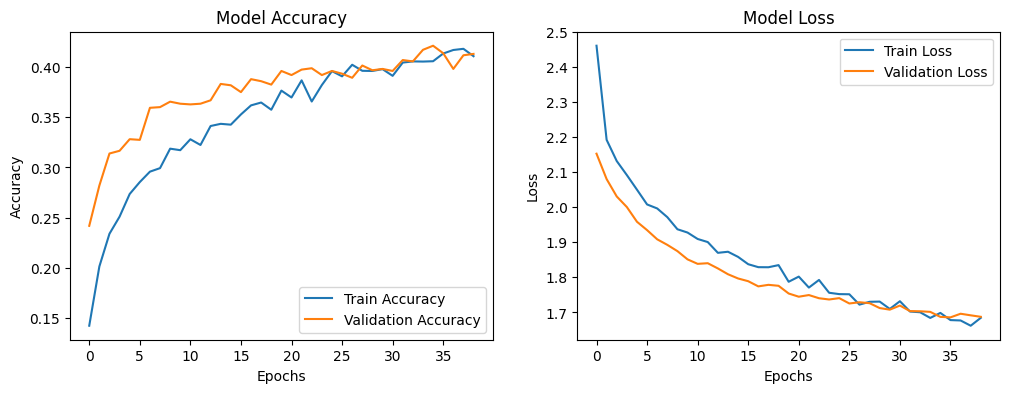

In [33]:
plot_accuracy_n_loss(history)

#### Fine-Tuning

In [35]:
# Unfreeze the base model for fine-tuning
base_model.trainable = True

# Recompile model with lower learning rate
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [36]:
# Fine-tune model
start_time = time.time()
fine_tune_history = model.fit(
    train_set,
    validation_data=val_set,
    epochs=EPOCHES,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VALIDATION_STEPS,
    callbacks=[early_stopping, lr_scheduler]
)
end_time = time.time()
fine_tuning_time = end_time - start_time

Epoch 1/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 130s 235ms/step - accuracy: 0.1976 - loss: 2.4382 - val_accuracy: 0.3512 - val_loss: 1.8429 - learning_rate: 1.0000e-05
Epoch 2/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 51s 272ms/step - accuracy: 0.3791 - loss: 1.7236 - val_accuracy: 0.4803 - val_loss: 1.4524 - learning_rate: 1.0000e-05
Epoch 3/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 52s 280ms/step - accuracy: 0.4919 - loss: 1.4124 - val_accuracy: 0.5788 - val_loss: 1.1725 - learning_rate: 1.0000e-05
Epoch 4/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 51s 272ms/step - accuracy: 0.5682 - loss: 1.1838 - val_accuracy: 0.6522 - val_loss: 0.9945 - learning_rate: 1.0000e-05
Epoch 5/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 50s 270ms/step - accuracy: 0.6425 - loss: 1.0510 - val_accuracy: 0.6909 - val_loss: 0.8778 - learning_rate: 1.0000e-05
Epoch 6/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 49s 264ms/step - accuracy: 0.6617 - loss: 0.9784 - val_accuracy: 0.7126 - val_loss: 0.8158 - learning_rate: 1.0000e-05
Epoch 7/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 60s 3

##### Accuracy and Loss Graph

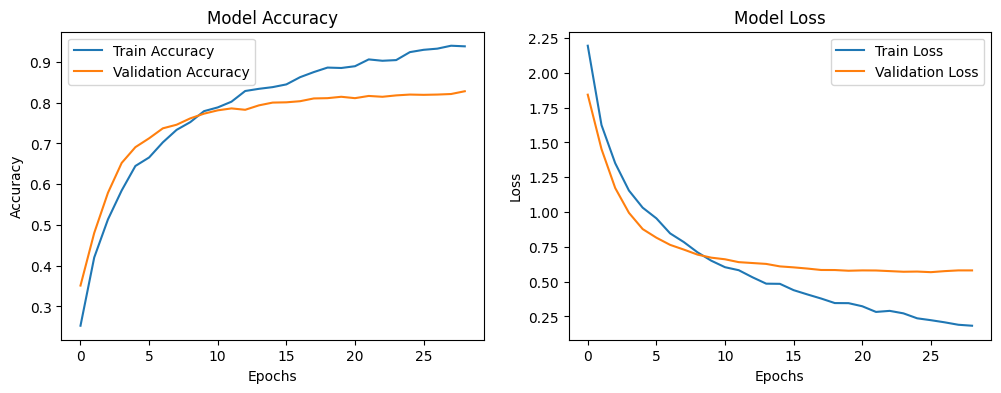

In [40]:
plot_accuracy_n_loss(fine_tune_history)

#### Evaluate Model

79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step
                   precision    recall  f1-score   support

        apple_pie       0.71      0.66      0.68       250
   baby_back_ribs       0.92      0.91      0.91       250
          baklava       0.84      0.88      0.86       250
   beef_carpaccio       0.89      0.87      0.88       250
     beef_tartare       0.84      0.89      0.86       250
       beet_salad       0.90      0.82      0.86       250
         beignets       0.90      0.95      0.92       250
         bibimbap       0.96      0.97      0.97       250
    bread_pudding       0.72      0.69      0.70       250
breakfast_burrito       0.88      0.91      0.89       250

         accuracy                           0.86      2500
        macro avg       0.85      0.86      0.85      2500
     weighted avg       0.85      0.86      0.85      2500

=== Initial Training ===
Average Training Accuracy: 0.3504
Average Validation Accuracy: 0.3765
Average Training Loss: 1.8471
Averag

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


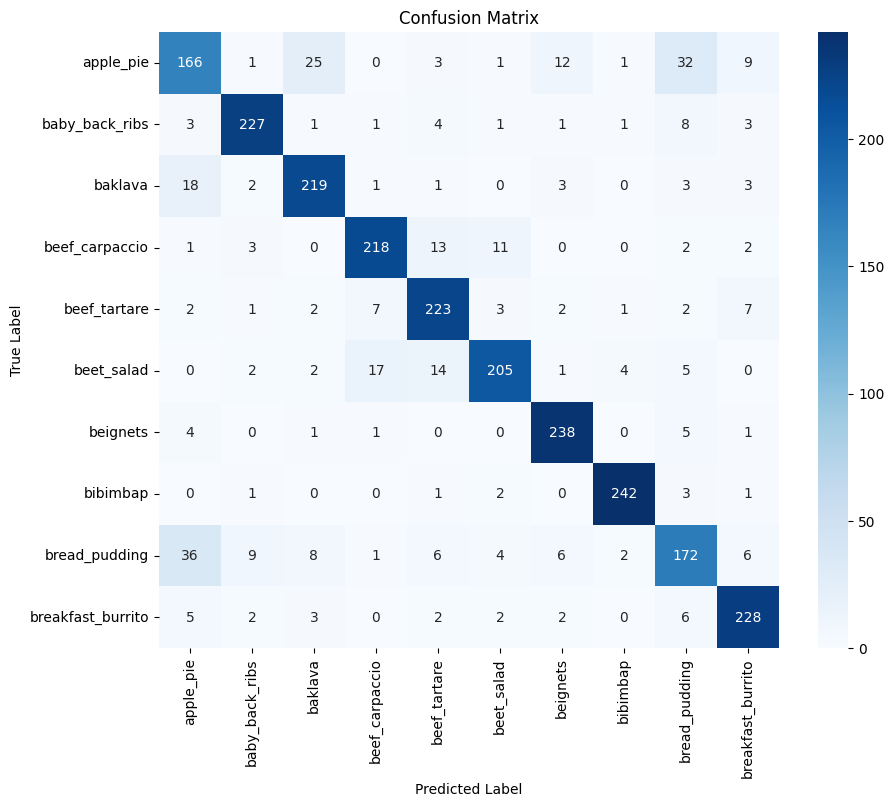

Initial Training Time: 1459.13 seconds
Fine-Tuning Time: 1319.78 seconds


In [56]:
# Generate predictions on validation dataset
# Store predictions in TensorFlow tensors (avoids NumPy conversion issues)
y_true = tf.concat([labels for _, labels in test_set], axis=0)
y_pred = tf.argmax(model.predict(test_set), axis=1)

# Classification Report
class_report = classification_report(y_true, y_pred, target_names=labels)
print(class_report)

# Calculate average accuracy and loss for training and validation (before fine-tuning)
avg_train_acc = np.mean(history.history['accuracy'])
avg_val_acc = np.mean(history.history['val_accuracy'])
avg_train_loss = np.mean(history.history['loss'])
avg_val_loss = np.mean(history.history['val_loss'])

# Calculate average accuracy and loss for training and validation (after fine-tuning)
avg_train_acc_fine = np.mean(fine_tune_history.history['accuracy'])
avg_val_acc_fine = np.mean(fine_tune_history.history['val_accuracy'])
avg_train_loss_fine = np.mean(fine_tune_history.history['loss'])
avg_val_loss_fine = np.mean(fine_tune_history.history['val_loss'])

# Display results
print("=== Initial Training ===")
print(f"Average Training Accuracy: {avg_train_acc:.4f}")
print(f"Average Validation Accuracy: {avg_val_acc:.4f}")
print(f"Average Training Loss: {avg_train_loss:.4f}")
print(f"Average Validation Loss: {avg_val_loss:.4f}\n")

print("=== After Fine-Tuning ===")
print(f"Average Training Accuracy (Fine-Tuned): {avg_train_acc_fine:.4f}")
print(f"Average Validation Accuracy (Fine-Tuned): {avg_val_acc_fine:.4f}")
print(f"Average Training Loss (Fine-Tuned): {avg_train_loss_fine:.4f}")
print(f"Average Validation Loss (Fine-Tuned): {avg_val_loss_fine:.4f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Display runtime performance
print(f"Initial Training Time: {initial_training_time:.2f} seconds")
print(f"Fine-Tuning Time: {fine_tuning_time:.2f} seconds")